# Deep Neural Network
In this notebook, we'll try to develope a deep neural network from scratch using nothing but pure *mathematical formulas* and *NumPy*. The goal is to understand the underlying structure of a deep learning model that is capable of learning non-linear trends in a set of data.

The dataset used for this practice is a circular data generated by hand.

In [58]:
import numpy as np
import matplotlib.pyplot as plt


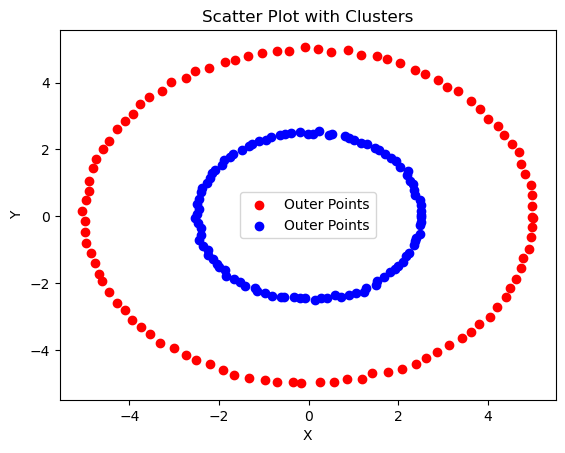

In [ ]:
np.random.seed(42)
n_points = 100
radius = 5

# circular data generation
angles = np.linspace(0, 2 * np.pi, n_points)

x_outer = radius * np.cos(angles) + np.random.randn(n_points) * 0.03
y_outer = radius * np.sin(angles) + np.random.randn(n_points) * 0.03

x_inner = (radius / 2) * np.cos(angles) + np.random.randn(n_points) * 0.03
y_inner = (radius / 2) * np.sin(angles) + np.random.randn(n_points) * 0.03

X = np.vstack([np.concatenate([x_outer, x_inner]), np.concatenate([y_outer, y_inner])])
Y = np.concatenate([np.zeros(n_points),np.ones(n_points)]).reshape(1, -1)

# Shuffle the data both features and labels at the same time to preserve the assigned labels
indices = np.random.permutation(X.shape[1])

X = X[:, indices]
Y = Y[:, indices]

# visualize data
plt.scatter(X[0, Y[0] == 0],X[1, Y[0] == 0], c='red', label='Outer Points')
plt.scatter(X[0, Y[0] ==1],X[1, Y[0] == 1], c='blue', label='Outer Points')

# Add labels and legend
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Scatter Plot with Clusters')
plt.legend()
plt.show()

## Parameters initialization
The following function provides three methods of initialization, zeros, random, and he.

In [71]:
def initialize_parameters(layer_dims, init_type = "random"):
    np.random.seed(3)
    parameters = {}
    L = len(layer_dims)

    if init_type == "zeros":
        for l in range(1,L):

            parameters[f"W{l}"] = np.zeros((layer_dims[l], layer_dims[l-1]))
            parameters[f"b{l}"] = np.zeros((layer_dims[l], 1)) 
            assert(parameters[f"W{l}"].shape == (layer_dims[l], layer_dims[l-1]))
            assert(parameters[f"b{l}"].shape == (layer_dims[l], 1))


    if init_type == "random":
        for l in range(1, L):

            parameters[f"W{l}"] = np.random.randn(layer_dims[l], layer_dims[l-1]) * 0.01
            parameters[f"b{l}"] = np.zeros((layer_dims[l], 1))
            assert(parameters[f"W{l}"].shape == (layer_dims[l], layer_dims[l-1]))
            assert(parameters[f"b{l}"].shape == (layer_dims[l], 1))

    if init_type == "he":
        for l in range(1, L):

            parameters[f"W{l}"] = np.random.randn(layer_dims[l], layer_dims[l-1]) * np.sqrt(2/layer_dims[l-1])
            parameters[f"b{l}"] = np.zeros((layer_dims[l], 1))
        assert(parameters[f"W{l}"].shape == (layer_dims[l], layer_dims[l-1]))
        assert(parameters[f"b{l}"].shape == (layer_dims[l], 1))

    return parameters

## Forward Propagation
In this section we will construct the elements needed for forward propagation such as *linear combination, activation function*. Then, we'll aggregate these functions in one general function that makes predictions by calling it.

In [ ]:
def linear(A, w, b):
    '''
    A : output of the activation from previous layer
    w : weights
    b : bias
    Z : output of the linear combiantion
    '''
    Z = np.dot(w, A) + b
    cache = (A, w, b)
    return Z, cache

def sigmoid(Z):
    a = 1/(1+np.exp(-Z))
    return a , Z

def relu(Z):
    a = np.maximum(0, Z)
    return a , Z

def compute_loss(AL, Y):
    m = Y.shape[1]
    cost = (-1/m) * (np.dot(Y, np.log(AL).T) + np.dot((1-Y), np.log(1-AL).T))
    # cost = -(np.sum(Y*np.log(AL)+(1-Y)*np.log(1-AL)))/m
    cost = np.squeeze(cost)
    assert(cost.shape == ())
    return cost

def linear_activation(A_prev, W, b, activation):
    ''''
    Input

    A_prev : output of the previous layer
    activation : type of activation function you wish to use

    output

    A : output of the activation function of the current layer
    cache : record of the linear and the activation outputs for backward propagation
    '''

    if activation == "relu":

        Z, linearcache = linear(A_prev, W, b)
        A, activationcache = relu(Z)

    if activation == "sigmoid":

        Z, linearcache = linear(A_prev, W, b)
        A, activationcache = sigmoid(Z)

    assert (A.shape == (W.shape[0], A_prev.shape[1]))
        
    cache = (linearcache, activationcache)
    return A, cache


In [ ]:
def L_layer_forward(X, parameters):

    caches = [] # keeps a sequential record of the caches for backward propagation
    A = X
    L = len(parameters)//2 #number of layers, divided by two because w + b

    for l in range(1,L):
        A_prev = A

        A, cache = linear_activation(A_prev, parameters["W" + str(l)], parameters["b" + str(l)], "relu")
        caches.append(cache)


    AL, cache = linear_activation(A, parameters["W" + str(L)], parameters["b" + str(L)], "sigmoid")
    caches.append(cache)

    assert(AL.shape==(1,X.shape[1]))

    return AL, caches

## Back Propagation
Now we implement the elements needed for a back propagation and the actual learning process. Then, just like forward pass, we gather all of them in a single function.

In [63]:
def linear_backward(dZ, cache):
    A_prev, W, b = cache

    m = A_prev.shape[1]

    dW = (1 / m) * np.dot(dZ, A_prev.T)
    db = (1 / m) * np.sum(dZ, axis=1, keepdims=True)
    dA_prev = np.dot(W.T, dZ)

    assert (dA_prev.shape == A_prev.shape)
    assert (dW.shape == W.shape)
    assert (db.shape == b.shape)
    return dA_prev, dW, db

def sigmoid_backward(dA, activation_cache):
    Z = activation_cache
    s = 1 / (1 + np.exp(-Z))
    dZ = dA * s * (1 - s)
    return dZ
def relu_backward(dA, activation_cache):
    Z = activation_cache
    dZ = np.array(dA, copy=True) # just converting dZ to a correct object.
    
    # When Z <= 0, we should set dZ to 0 as well.
    dZ[Z <= 0] = 0
    
    return dZ

def linear_activation_backward(dA, cache, activation):
    linear_cache, activation_cache = cache

    if activation == "relu":

        dZ = relu_backward(dA, activation_cache)
        
    elif activation == "sigmoid":

        dZ = sigmoid_backward(dA, activation_cache)

    dA_prev, dW, db = linear_backward(dZ, linear_cache)        
        
    return dA_prev, dW, db

def backward_propagation(AL, Y, caches):

    grads = {}
    L = len(caches) # the number of layers
    m = AL.shape[1]
    Y = Y.reshape(AL.shape) # after this line, Y is the same shape as AL

    dAL = - (np.divide(Y, AL) - np.divide(1 - Y, 1 - AL))

    current_cache = caches[L-1]

    grads["dA" + str(L-1)], grads["dW" + str(L)], grads["db" + str(L)] = linear_activation_backward(dAL, current_cache, "sigmoid")

    for l in reversed(range(L-1)):

        current_cache = caches[l]
        dA_prev_temp, dW_temp, db_temp = linear_activation_backward(grads["dA" + str(l + 1)], current_cache, activation = "relu")
        grads["dA" + str(l)] = dA_prev_temp
        grads["dW" + str(l + 1)] = dW_temp
        grads["db" + str(l + 1)] = db_temp
    return grads
def update_parameters(parameters, grads, learning_rate):


    L = len(parameters) // 2 # number of layers in the neural network

    for l in range(L):

        parameters[f"W" + str(l+1)] = parameters[f"W" + str(l+1)] - learning_rate * grads[f"dW" + str(l+1)]
        parameters[f"b" + str(l+1)] = parameters[f"b" + str(l+1)] - learning_rate * grads[f"db" + str(l+1)]

    return parameters

## Model
Now it's time to assemble all the pieces together to create our model. By running the following function, you will automatically pass the data through a neural network for a given number of iterations. As a result, you will get the parameters for which the model system makes predictions with lowest error.

In [ ]:
def model(X, Y, learning_rate = 0.01, num_iterations = 15000, print_cost = True, initialization = "he"):
    """    
    input

    X : training instances
    Y : labes, target values
    num_iterations : number of times the prediction and evaluation will be made

    output

    parameters : the parameters for which we have the results with lowest cost
    """
        
    grads = {}
    costs = [] # to keep track of the loss
    m = X.shape[1] # number of examples
    layers_dims = [X.shape[0], 10, 5, 1]
    
    # Initialize parameters dictionary.
    parameters = initialize_parameters(layers_dims, initialization)

    # Loop (gradient descent)

    for i in range(num_iterations):

        # Forward propagation: LINEAR -> RELU -> LINEAR -> RELU -> LINEAR -> SIGMOID.
        AL, cache = L_layer_forward(X, parameters)
        
        # Loss
        cost = compute_loss(AL, Y)

        # Backward propagation.
        grads = backward_propagation(AL, Y, cache)
        
        # Update parameters.
        parameters = update_parameters(parameters, grads, learning_rate)
        
        # Print the loss every 1000 iterations
        if print_cost and i % 1000 == 0:
            print("Cost after iteration {}: {}".format(i, cost))
            costs.append(cost)
            
    # plot the loss
    plt.plot(costs)
    plt.ylabel('cost')
    plt.xlabel('iterations (per hundreds)')
    plt.title("Learning rate =" + str(learning_rate))
    plt.show()
    
    return parameters

Cost after iteration 0: 0.6931493868208066
Cost after iteration 1000: 0.6931481128719189
Cost after iteration 2000: 0.6931473094768277
Cost after iteration 3000: 0.6931464920347509
Cost after iteration 4000: 0.6931453608319668
Cost after iteration 5000: 0.6931444790212368
Cost after iteration 6000: 0.6931434319036883
Cost after iteration 7000: 0.6931421448658149
Cost after iteration 8000: 0.6931405158984577
Cost after iteration 9000: 0.6931383989938388
Cost after iteration 10000: 0.6931356650605901
Cost after iteration 11000: 0.6931319513038292
Cost after iteration 12000: 0.6931268091513204
Cost after iteration 13000: 0.6931194151347114
Cost after iteration 14000: 0.6931083773165665


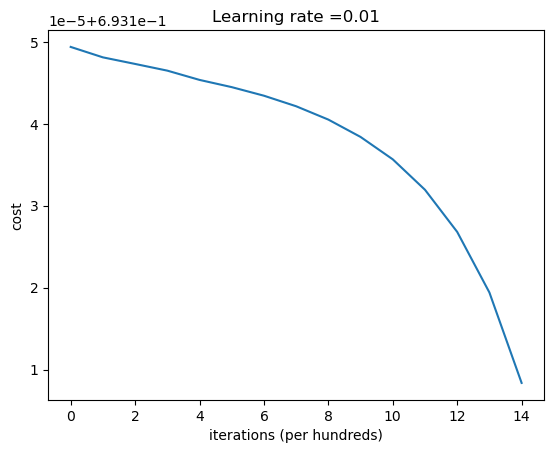

In [66]:
m = model(X, Y, learning_rate = 0.01, num_iterations = 15000, print_cost = True, initialization = "random")

Cost after iteration 0: 2.690332454665516
Cost after iteration 1000: 0.4533582803998364
Cost after iteration 2000: 0.21577513622524486
Cost after iteration 3000: 0.07874346122296301
Cost after iteration 4000: 0.038935153058922575
Cost after iteration 5000: 0.026155083267119322
Cost after iteration 6000: 0.020029518798059334
Cost after iteration 7000: 0.016178573159234585
Cost after iteration 8000: 0.01367450074963644
Cost after iteration 9000: 0.011877900370519534
Cost after iteration 10000: 0.01054373177738303
Cost after iteration 11000: 0.009505757170523935
Cost after iteration 12000: 0.008668441399693694
Cost after iteration 13000: 0.00794433010769844
Cost after iteration 14000: 0.007321236336843664


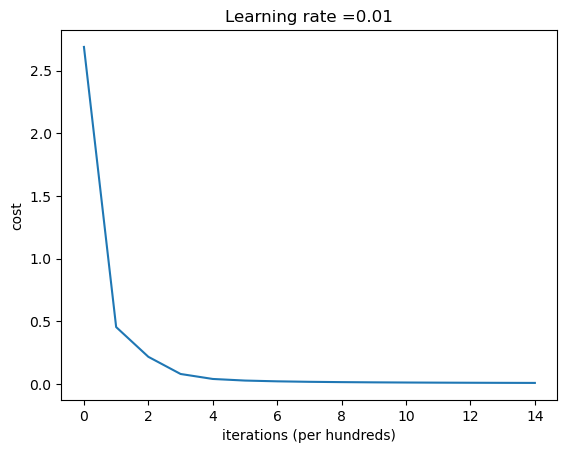

In [68]:
m = model(X, Y, learning_rate = 0.01, num_iterations = 15000, print_cost = True, initialization = "he")